## 1) Instalando bibliotecas

In [9]:
import pandas as pd
import requests
import zipfile
import io
from sqlalchemy import create_engine, text, inspect
import os
from dotenv import load_dotenv
from urllib.parse import quote_plus
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

## 2) Obtendo dados referentes ao Formulário de Referência (FRE) da CVM

### 2.1) Configurações principais para a coleta de dados do FRE

In [10]:
# ==============================================================================
# 1. CONFIGURAÇÕES & CONEXÃO
# ==============================================================================

# Carrega as variáveis do arquivo .env
load_dotenv()

# ==============================================================================
# 1. CONFIGURAÇÕES SEGURAS (COM DOTENV)
# ==============================================================================

# Busca as credenciais nas variáveis de ambiente
DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

# Tratamento de caracteres especiais (Isso resolve o problema do @ e do ç)
# O quote_plus transforma 'senha@123' em 'senha%40123' automaticamente
encoded_user = quote_plus(DB_USER)
encoded_pass = quote_plus(DB_PASS)

# Monta a string de conexão segura
DB_CONNECTION = f"postgresql+psycopg2://{encoded_user}:{encoded_pass}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Schema Bronze
SCHEMA_BRONZE = 'layer_01_bronze'
BASE_URL_CVM = 'http://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/FRE/DADOS/'

### 2.2) Funções principais para a coleta de dados do FRE

In [11]:
# ==============================================================================
# 2. FUNÇÕES DE SUPORTE (ENGINEERING TOOLS)
# ==============================================================================

def criar_engine_db():
    return create_engine(DB_CONNECTION)

def configurar_tabela_logs(engine):
    """
    Cria a tabela de logs dentro do schema layer_01_bronze.
    Essa tabela conta a história da execução.
    """
    query_create_log = f"""
    CREATE TABLE IF NOT EXISTS {SCHEMA_BRONZE}.fre_raw_logs_by_timestamp (
        log_id SERIAL PRIMARY KEY,
        data_execucao TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        nivel_log VARCHAR(50),
        ano_referencia INT,
        arquivo_origem VARCHAR(200),
        tabela_destino VARCHAR(200),
        mensagem TEXT,
        schema_drift_detectado BOOLEAN DEFAULT FALSE
    );
    """
    with engine.connect() as conn:
        # Garante que o schema existe
        conn.execute(text(f"CREATE SCHEMA IF NOT EXISTS {SCHEMA_BRONZE};"))
        conn.execute(text(query_create_log))
        conn.commit()
    print(f"✅ Setup: Tabela de logs verificada em {SCHEMA_BRONZE}.")

def registrar_log(engine, nivel, ano, arquivo, tabela, msg, drift=False):
    """Insere o registro no banco."""
    query = text(f"""
        INSERT INTO {SCHEMA_BRONZE}.fre_raw_logs_by_timestamp 
        (nivel_log, ano_referencia, arquivo_origem, tabela_destino, mensagem, schema_drift_detectado, data_execucao)
        VALUES (:niv, :ano, :arq, :tab, :msg, :drift, NOW())
    """)
    with engine.connect() as conn:
        conn.execute(query, {'niv': nivel, 'ano': ano, 'arq': arquivo, 'tab': tabela, 'msg': msg, 'drift': drift})
        conn.commit()
    
    # Feedback visual para o aluno
    icon = "🟢" if nivel == 'SUCCESS' else "🟡" if nivel == 'WARNING' else "🔴"
    print(f"{icon} [{nivel}] {msg}")

def verificar_carga_existente(engine, nome_arquivo_zip):
    """Idempotência: Verifica se este ZIP já foi carregado com sucesso."""
    query = text(f"""
        SELECT 1 FROM {SCHEMA_BRONZE}.fre_raw_logs_by_timestamp
        WHERE arquivo_origem = :arq 
          AND nivel_log = 'SUCCESS'
          AND mensagem LIKE 'Processamento do ZIP finalizado%'
    """)
    with engine.connect() as conn:
        return conn.execute(query, {'arq': nome_arquivo_zip}).fetchone() is not None

def verificar_schema_drift(engine, nome_tabela, df_novo):
    """
    🕵️ DETETIVE DE DADOS:
    Compara as colunas do DataFrame novo com as colunas que já existem na tabela do banco.
    Retorna uma mensagem se houver colunas novas (Drift).
    """
    inspector = inspect(engine)
    
    # Se a tabela não existe, não há drift, é a primeira carga (Full Load)
    if not inspector.has_table(nome_tabela, schema=SCHEMA_BRONZE):
        return False, "Tabela Nova (Primeira Carga)"

    # Pega colunas do banco
    colunas_banco = [col['name'] for col in inspector.get_columns(nome_tabela, schema=SCHEMA_BRONZE)]
    colunas_novo_arquivo = df_novo.columns.tolist()

    # Compara conjuntos (Set Difference)
    novas_colunas = set(colunas_novo_arquivo) - set(colunas_banco)

    if novas_colunas:
        return True, f"⚠️ Schema Drift Detectado! Novas colunas encontradas: {novas_colunas}"
    
    return False, "Estrutura mantida (Sem alterações)"

# ==============================================================================
# 3. ETL PRINCIPAL
# ==============================================================================

def run_etl_pipeline():
    engine = criar_engine_db()
    configurar_tabela_logs(engine)
    
    ano_atual = datetime.datetime.now().year
    lista_anos = range(2010, ano_atual + 1)

    # ------------------------------------------------------------------
    # TRUQUE DE ENGENHARIA: HEADERS (User-Agent)
    # Isso faz o Python fingir que é um navegador Chrome para não ser bloqueado
    # ------------------------------------------------------------------
    headers_navegador = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    print(f"\n🚀 Iniciando varredura de 2010 até {ano_atual} com identidade de navegador...\n")

    for ano in lista_anos:
        nome_arquivo_zip = f"fre_cia_aberta_{ano}.zip"
        
        # Dica: Use HTTPS para evitar problemas de redirecionamento
        url_download = f"https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/FRE/DADOS/{nome_arquivo_zip}"
        
        # Verificação de Idempotência
        if verificar_carga_existente(engine, nome_arquivo_zip):
            print(f"⏭️  Ano {ano} já processado. Pulando.")
            continue

        # 1. Verificação de Existência (Agora passando os headers!)
        try:
            check_response = requests.head(url_download, headers=headers_navegador, timeout=10)
            
            # Se der erro (403, 404, 500), a gente loga e pula
            if check_response.status_code != 200:
                msg_erro = f"Falha no acesso HTTP. Status Code: {check_response.status_code}"
                print(f"❌ {msg_erro} para o ano {ano}")
                
                # AGORA SIM: Gravamos no log por que falhou
                registrar_log(engine, 'ERROR', ano, nome_arquivo_zip, '-', msg_erro)
                continue
                
        except Exception as e:
            registrar_log(engine, 'ERROR', ano, nome_arquivo_zip, '-', f"Erro de conexão ao checar arquivo: {e}")
            continue

        try:
            # 2. Download Real (Passando headers novamente)
            registrar_log(engine, 'INFO', ano, nome_arquivo_zip, '-', 'Iniciando Download...')
            r = requests.get(url_download, headers=headers_navegador, timeout=60)
            
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                arquivos_csv = [f for f in z.namelist() if f.endswith('.csv')]
                
                if not arquivos_csv:
                    registrar_log(engine, 'WARNING', ano, nome_arquivo_zip, '-', 'Zip vazio.')
                    continue

                for csv_file in arquivos_csv:
                    nome_base = csv_file.lower().replace(f'_{ano}.csv', '').replace('.csv', '')
                    if not nome_base.startswith('fre_'):
                        nome_tabela_final = f"fre_{nome_base}"
                    else:
                        nome_tabela_final = nome_base

                    try:
                        with z.open(csv_file) as f:
                            df = pd.read_csv(f, sep=';', encoding='windows-1252', on_bad_lines='skip', low_memory=False)
                        
                        df['metadata_data_carga'] = datetime.datetime.now()
                        df['metadata_arquivo_origem'] = csv_file
                        df = df.astype(str)

                        # Verificação de Drift
                        is_drift, msg_drift = verificar_schema_drift(engine, nome_tabela_final, df)
                        if is_drift:
                            registrar_log(engine, 'WARNING', ano, csv_file, nome_tabela_final, msg_drift, drift=True)
                        
                        # Carga
                        df.to_sql(
                            nome_tabela_final, 
                            engine, 
                            schema=SCHEMA_BRONZE, 
                            if_exists='append', 
                            index=False,
                            method='multi',
                            chunksize=1000
                        )
                        
                        registrar_log(engine, 'INFO', ano, csv_file, nome_tabela_final, f"Sucesso: {len(df)} linhas.")

                    except Exception as e:
                        registrar_log(engine, 'ERROR', ano, csv_file, nome_tabela_final, f"Erro no CSV: {str(e)}")

            registrar_log(engine, 'SUCCESS', ano, nome_arquivo_zip, 'TODAS', 'Processamento do ZIP finalizado.')

        except Exception as e:
            registrar_log(engine, 'FATAL', ano, nome_arquivo_zip, '-', f"Erro crítico no download: {str(e)}")

### 2.3) Rodando de fato a coleta dos dados de FRE para o nosso banco local Postgresql

In [12]:
if __name__ == "__main__":
    run_etl_pipeline()

✅ Setup: Tabela de logs verificada em layer_01_bronze.

🚀 Iniciando varredura de 2010 até 2026 com identidade de navegador...

🔴 [INFO] Iniciando Download...
🔴 [INFO] Sucesso: 2783 linhas.
🔴 [INFO] Sucesso: 8041 linhas.
🔴 [INFO] Sucesso: 6240 linhas.
🔴 [INFO] Sucesso: 7232 linhas.
🔴 [INFO] Sucesso: 714 linhas.
🔴 [INFO] Sucesso: 722 linhas.
🔴 [INFO] Sucesso: 1746 linhas.
🔴 [INFO] Sucesso: 1435 linhas.
🔴 [INFO] Sucesso: 181 linhas.
🔴 [INFO] Sucesso: 372 linhas.
🔴 [INFO] Sucesso: 205 linhas.
🔴 [INFO] Sucesso: 43 linhas.
🔴 [INFO] Sucesso: 132 linhas.
🔴 [INFO] Sucesso: 14 linhas.
🔴 [INFO] Sucesso: 44 linhas.
🔴 [INFO] Sucesso: 837 linhas.
🔴 [INFO] Sucesso: 651 linhas.
🔴 [INFO] Sucesso: 274 linhas.
🔴 [INFO] Sucesso: 1166 linhas.
🔴 [INFO] Sucesso: 3190 linhas.
🔴 [INFO] Sucesso: 724 linhas.
🔴 [INFO] Sucesso: 1960 linhas.
🔴 [INFO] Sucesso: 652 linhas.
🔴 [INFO] Sucesso: 11429 linhas.
🔴 [INFO] Sucesso: 2468 linhas.
🔴 [INFO] Sucesso: 1070 linhas.
🔴 [INFO] Sucesso: 1029 linhas.
🔴 [INFO] Sucesso: 386

## 3) Conferindo os registros que subiram para o banco local postgresql - Grandes Números

In [13]:
# DB_CONNECTION já foi definida lá no passo 2.1 anteriormente
engine = create_engine(DB_CONNECTION)

In [14]:
# Query Híbrida: Traz o texto formatado (para ler) e o número cru (para plotar)
query_auditoria_completa = """
SELECT 
    relname AS nome_tabela,
    
    -- Colunas Formatadas (Para leitura humana)
    TO_CHAR(n_live_tup, 'FM999,999,999,999') AS linhas_txt,
    pg_size_pretty(pg_total_relation_size(relid)) AS total_disco_txt,
    pg_size_pretty(pg_relation_size(relid)) AS apenas_dados_txt,
    pg_size_pretty(pg_total_relation_size(relid) - pg_relation_size(relid)) AS apenas_indices_txt,

    -- Colunas Numéricas (Para gráficos e DataViz)
    n_live_tup AS qtd_linhas_int,
    pg_total_relation_size(relid) AS total_disco_bytes,
    pg_relation_size(relid) AS apenas_dados_bytes,
    (pg_total_relation_size(relid) - pg_relation_size(relid)) AS apenas_indices_bytes

FROM pg_stat_user_tables
WHERE schemaname = 'layer_01_bronze'
ORDER BY pg_total_relation_size(relid) DESC;
"""

# Executa e carrega no Pandas
df_auditoria = pd.read_sql(query_auditoria_completa, engine)

In [15]:
df_auditoria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   nome_tabela           62 non-null     object
 1   linhas_txt            62 non-null     object
 2   total_disco_txt       62 non-null     object
 3   apenas_dados_txt      62 non-null     object
 4   apenas_indices_txt    62 non-null     object
 5   qtd_linhas_int        62 non-null     int64 
 6   total_disco_bytes     62 non-null     int64 
 7   apenas_dados_bytes    62 non-null     int64 
 8   apenas_indices_bytes  62 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 4.5+ KB


In [16]:
df_auditoria.head()

,nome_tabela,linhas_txt,total_disco_txt,apenas_dados_txt,apenas_indices_txt,qtd_linhas_int,total_disco_bytes,apenas_dados_bytes,apenas_indices_bytes
0,fre_cia_aberta_administrador_membro_conselho_f...,"136,647",190 MB,179 MB,11 MB,136647,199680000,187801600,11878400
1,fre_cia_aberta_ativo_intangivel,"174,232",155 MB,154 MB,1128 kB,174232,162111488,160956416,1155072
2,fre_cia_aberta_posicao_acionaria,"397,468",130 MB,130 MB,72 kB,397468,136593408,136519680,73728
3,fre_cia_aberta_transacao_parte_relacionada,"163,324",106 MB,102 MB,3488 kB,163324,111026176,107454464,3571712
4,fre_cia_aberta_outro_valor_mobiliario,"39,202",73 MB,48 MB,25 MB,39202,76136448,50028544,26107904


AttributeError: module 'datetime' has no attribute 'now'

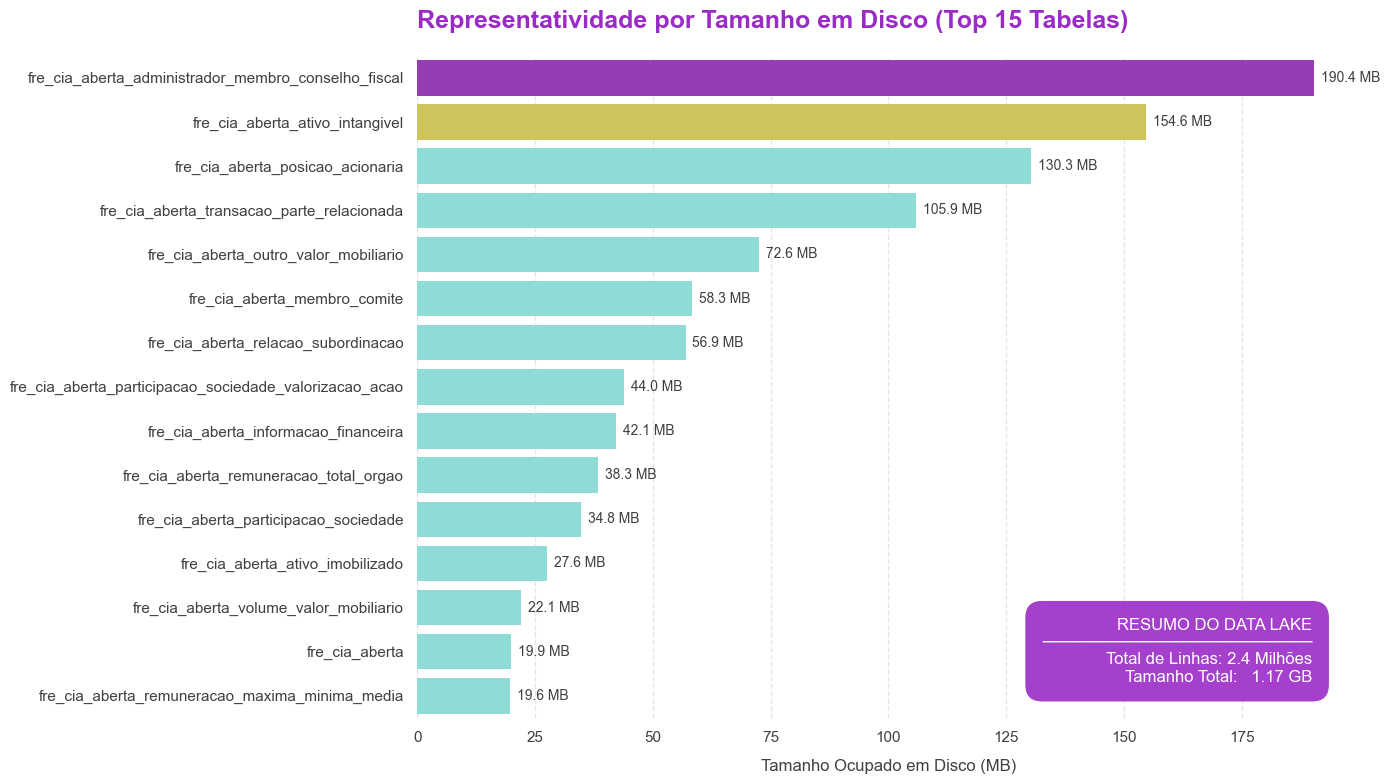

In [17]:
# ==============================================================================
# 1. CONFIGURAÇÃO DE ESTILO (IDENTIDADE VISUAL FAE)
# ==============================================================================
cores_fae = {
    'roxo': '#9B2BC7',
    'dourado': '#E0D449',
    'azul_esverdeado': '#82E8E1',
    'amarelo_claro': '#F6ED52',
    'cinza_claro': '#F0F0F0',
    'cinza_escuro': '#404040'
}

# Configurando o tema base do Seaborn para ficar limpo
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = cores_fae['cinza_escuro']
plt.rcParams['axes.labelcolor'] = cores_fae['cinza_escuro']
plt.rcParams['xtick.color'] = cores_fae['cinza_escuro']
plt.rcParams['ytick.color'] = cores_fae['cinza_escuro']

# ==============================================================================
# 2. PREPARAÇÃO DOS DADOS
# ==============================================================================
# Certifique-se de que 'df_auditoria' já foi carregado na célula anterior!
if 'df_auditoria' not in locals():
    print("⚠️ ALERTA: O DataFrame 'df_auditoria' não foi encontrado. Rode a query SQL primeiro.")
else:
    # Vamos focar nas top 15 tabelas para o gráfico não ficar gigante
    df_viz = df_auditoria.sort_values('total_disco_bytes', ascending=False).head(15).copy()

    # Calculando KPIs para exibir
    total_linhas_milhoes = df_auditoria['qtd_linhas_int'].sum() / 1_000_000
    total_tamanho_gb = df_auditoria['total_disco_bytes'].sum() / (1024**3)

    # Criando uma coluna de tamanho em MB para facilitar a leitura no gráfico
    df_viz['tamanho_mb'] = df_viz['total_disco_bytes'] / (1024**2)

    # ==============================================================================
    # 3. PLOTAGEM
    # ==============================================================================
    # Criando a figura e os eixos (tamanho A4 paisagem aproximado)
    fig, ax = plt.subplots(figsize=(14, 8))

    # O Gráfico de Barras
    bar_plot = sns.barplot(
        data=df_viz,
        x='tamanho_mb',
        y='nome_tabela',
        hue='nome_tabela', # <--- CORREÇÃO IMPORTANTE PARA SEABORN NOVO
        palette=[cores_fae['roxo'], cores_fae['dourado']] + [cores_fae['azul_esverdeado']]*(len(df_viz)-2), 
        ax=ax,
        edgecolor='none',
        legend=False       # <--- Remove a legenda redundante gerada pelo hue
    )

    # ==============================================================================
    # 4. CUSTOMIZAÇÃO E ACABAMENTO
    # ==============================================================================

    # Títulos e Subtítulos
    plt.title('Representatividade por Tamanho em Disco (Top 15 Tabelas)', 
              fontsize=18, fontweight='bold', color=cores_fae['roxo'], loc='left', pad=20)

    plt.xlabel('Tamanho Ocupado em Disco (MB)', fontsize=12, labelpad=10)
    plt.ylabel('', fontsize=12)

    # Adicionando o KPI de Total de Linhas
    kpi_text = (
        f"RESUMO DO DATA LAKE\n"
        f"───────────────────────\n"
        f"Total de Linhas: {total_linhas_milhoes:.1f} Milhões\n"
        f"Tamanho Total:   {total_tamanho_gb:.2f} GB"
    )

    # Caixa de texto no canto inferior direito
    plt.text(
        0.95, 0.05, kpi_text, 
        transform=ax.transAxes, 
        fontsize=12, 
        color='white',
        backgroundcolor=cores_fae['roxo'],
        ha='right', va='bottom',
        bbox=dict(facecolor=cores_fae['roxo'], alpha=0.9, boxstyle='round,pad=1', edgecolor='none')
    )

    # Adicionando os valores na ponta das barras
    for i, container in enumerate(ax.containers):
        ax.bar_label(container, fmt='%.1f MB', padding=5, color=cores_fae['cinza_escuro'], fontsize=10)

    # Limpeza final
    sns.despine(left=True, bottom=True)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.grid(False)

    plt.tight_layout()

    # Obtém a data e hora atual formatada
    data_hora = datetime.now().strftime("%d/%m/%Y %H:%M:%S")

    # Adiciona o texto no canto inferior direito
    # x=1, y=0 (canto inferior direito)
    # transform=ax.transAxes (usa coordenadas relativas ao gráfico, 0 a 1)
    plt.text(1, -0.1, f'Gerado em: {data_hora}',
            transform=plt.gca().transAxes, # Pega o eixo atual
            color='gray',
            ha='right', # Alinhamento horizontal à direita
            va='top',   # Alinhamento vertical ao topo
            fontsize=10,
            alpha=0.7)  # Transparência para ficar suave

    plt.show()